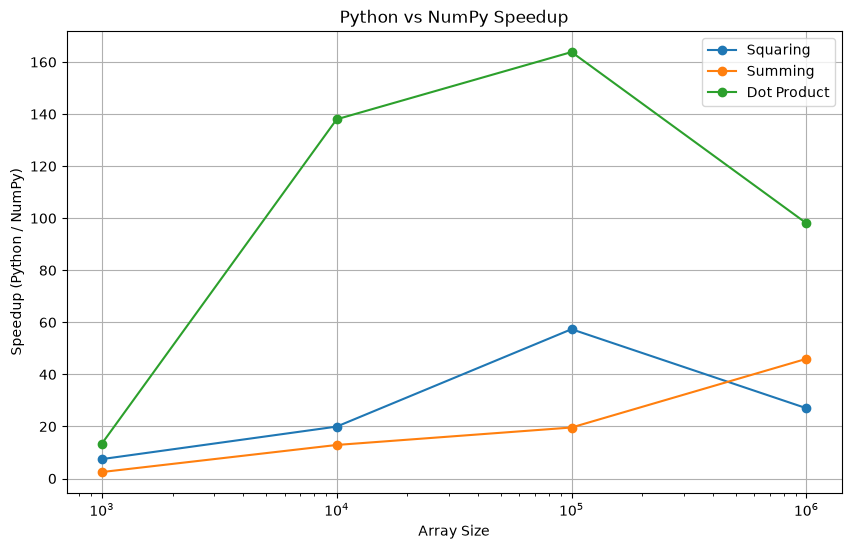

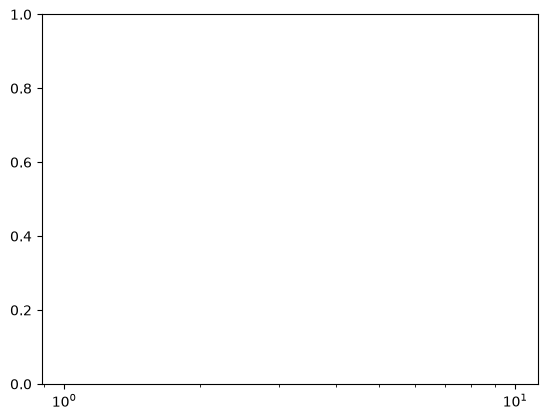

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["size"],
    df["square_speedup"],
    marker="o",
    label="Squaring"
)

plt.plot(
    df["size"],
    df["sum_speedup"],
    marker="o",
    label="Summing"
)

plt.plot(
    df["size"],
    df["dot_speedup"],
    marker="o",
    label="Dot Product"
)

plt.xscale("log")
plt.xlabel("Array Size")
plt.ylabel("Speedup (Python / NumPy)")
plt.title("Python vs NumPy Speedup")
plt.legend()
plt.grid(True)

plt.show()
plt.xscale("log")

### Task 03 — Observations

NumPy starts to show a clear performance advantage at around 100000 elements based on my measurements.

NumPy can have little advantage for very small arrays because there is a fixed overhead involved in calling and performing the NumPy operation. As the array becomes larger, NumPy's optimized numerical operations become much more efficient compared with Python-level loops.

In [1]:
sizes = [1_000, 10_000, 100_000, 1_000_000]

results = []

for n in sizes:
    setup = f"""
import numpy as np

lst_a = list(range({n}))
lst_b = list(range({n}, {2 * n}))

arr_a = np.arange({n})
arr_b = np.arange({n}, {2 * n})
"""

    # 1. Square every element
    python_square = timeit.timeit(
        "[x * x for x in lst_a]",
        setup=setup,
        number=10
    ) / 10

    numpy_square = timeit.timeit(
        "arr_a ** 2",
        setup=setup,
        number=10
    ) / 10

    # 2. Sum all elements
    python_sum = timeit.timeit(
        "sum(lst_a)",
        setup=setup,
        number=10
    ) / 10

    numpy_sum = timeit.timeit(
        "arr_a.sum()",
        setup=setup,
        number=10
    ) / 10

    # 3. Dot product
    python_dot = timeit.timeit(
        "sum(x * y for x, y in zip(lst_a, lst_b))",
        setup=setup,
        number=10
    ) / 10

    numpy_dot = timeit.timeit(
        "np.dot(arr_a, arr_b)",
        setup=setup,
        number=10
    ) / 10

    results.append({
        "size": n,
        "square_python": python_square,
        "square_numpy": numpy_square,
        "square_speedup": python_square / numpy_square,
        "sum_python": python_sum,
        "sum_numpy": numpy_sum,
        "sum_speedup": python_sum / numpy_sum,
        "dot_python": python_dot,
        "dot_numpy": numpy_dot,
        "dot_speedup": python_dot / numpy_dot,
    })

NameError: name 'timeit' is not defined

In [26]:
import pandas as pd

df = pd.DataFrame(results)

display(df)

,size,square_python,square_numpy,square_speedup,sum_python,sum_numpy,sum_speedup,dot_python,dot_numpy,dot_speedup
0,1000,0.000044,0.000006,7.459732,0.000005,0.000002,2.490826,0.000066,0.000005,13.387879
1,10000,0.000286,0.000014,19.956764,0.000059,0.000005,12.895652,0.001216,0.000009,138.005679
2,100000,0.005357,0.000093,57.366420,0.001577,0.000080,19.604177,0.007550,0.000046,163.836155
3,1000000,0.053038,0.001963,27.012350,0.017703,0.000385,45.983713,0.073031,0.000745,98.074814


In [22]:
import timeit

setup = """
import numpy as np
lst = list(range(100000))
arr = np.arange(100000)
"""

python_time = timeit.timeit(
    "[x * x for x in lst]",
    setup=setup,
    number=10
) / 10

numpy_time = timeit.timeit(
    "arr ** 2",
    setup=setup,
    number=10
) / 10

print("Python time:", python_time)
print("NumPy time:", numpy_time)
print("Speedup:", python_time / numpy_time)

Python time: 0.00403175999999803
NumPy time: 0.00019879999999830033
Speedup: 20.280482897547788


In [21]:
import numpy as np
import timeit
import matplotlib.pyplot as plt

In [20]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

rows = np.vstack((a, b))
columns = np.column_stack((a, b))

print("As rows:")
print(rows)

print("As columns:")
print(columns)

As rows:
[[1 2 3]
 [4 5 6]]
As columns:
[[1 4]
 [2 5]
 [3 6]]


In [19]:
a = np.array([
    [10, 20, 30],
    [40, 90, 60],
    [70, 80, 50]
])

flat_index = np.argmax(a)
position = np.unravel_index(flat_index, a.shape)

print("Largest value:", a.flat[flat_index])
print("Flat index:", flat_index)
print("Position (row, column):", position)

Largest value: 90
Flat index: 4
Position (row, column): (np.int64(1), np.int64(1))


In [18]:
border = np.zeros((5, 5), dtype=int)

border[0, :] = 1
border[-1, :] = 1
border[:, 0] = 1
border[:, -1] = 1

print(border)

[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]


In [17]:
data = np.array([
    [10, 100, 1000],
    [20, 200, 2000],
    [30, 300, 3000],
    [40, 400, 4000]
], dtype=float)

mean = data.mean(axis=0)
std = data.std(axis=0)

standardized = (data - mean) / std

print("Mean:", mean)
print("Standard deviation:", std)
print("Standardized:")
print(standardized)

print("New column means:", standardized.mean(axis=0))
print("New column std:", standardized.std(axis=0))

Mean: [  25.  250. 2500.]
Standard deviation: [  11.18033989  111.80339887 1118.03398875]
Standardized:
[[-1.34164079 -1.34164079 -1.34164079]
 [-0.4472136  -0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079  1.34164079]]
New column means: [0. 0. 0.]
New column std: [1. 1. 1.]


In [16]:
row_sums = grid.sum(axis=1)
column_sums = grid.sum(axis=0)

print("Row sums:", row_sums)
print("Column sums:", column_sums)

Row sums: [10 26 42 58]
Column sums: [28 32 36 40]


In [15]:
second_column = grid[:, 1]
last_two_rows = grid[-2:]

print("Second column:")
print(second_column)

print("Last two rows:")
print(last_two_rows)

Second column:
[ 2  6 10 14]
Last two rows:
[[ 9 10 11 12]
 [13 14 15 16]]


In [14]:
import numpy as np

grid = np.arange(1, 17).reshape(4, 4)

print(grid)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]


In [13]:
import numpy as np

grid = np.arange(1, 17).reshape(4, 4)

print(grid)
print("Shape:", grid.shape)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
Shape: (4, 4)


In [12]:
grid = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("Before:")
print(grid)

grid[[0, -1]] = grid[[-1, 0]]

print("After swapping first and last rows:")
print(grid)

Before:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
After swapping first and last rows:
[[7 8 9]
 [4 5 6]
 [1 2 3]]


In [10]:
a = np.array([10, 25, 30, 50, 75, 80])

mask = (a >= 25) & (a <= 75)

print("Array:", a)
print("Mask:", mask)
print("Values between 25 and 75:", a[mask])
print("Count:", mask.sum())

Array: [10 25 30 50 75 80]
Mask: [False  True  True  True  True False]
Values between 25 and 75: [25 30 50 75]
Count: 4


In [9]:
import numpy as np

arr = np.array([10, 20, 30, 40, 50])

mean = np.mean(arr)

print("Array:", arr)
print("Mean:", mean)
print("Elements greater than mean:", arr[arr > mean])

Array: [10 20 30 40 50]
Mean: 30.0
Elements greater than mean: [40 50]


In [11]:
a = np.array([42, 17, 91, 63, 28, 75, 54, 88, 12, 69])

largest_5 = np.sort(a)[::-1][:5]

print("Original array:", a)
print("5 largest values:", largest_5)

Original array: [42 17 91 63 28 75 54 88 12 69]
5 largest values: [91 88 75 69 63]


In [8]:
rng = np.random.default_rng(42)

a = rng.integers(1, 21, size=20)

print("Original:")
print(a)

a[a % 2 == 1] = -1

print("After replacing odd numbers:")
print(a)

Original:
[ 2 16 14  9  9 18  2 14  5  2 11 20 15 16 15 16 11  3 17 10]
After replacing odd numbers:
[ 2 16 14 -1 -1 18  2 14 -1  2 -1 20 -1 16 -1 16 -1 -1 -1 10]


In [6]:
arr = np.arange(0,20)
result = arr[::3]

print("original:",arr)
print("every third element:",result)

original: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
every third element: [ 0  3  6  9 12 15 18]


In [5]:
arr = np.zeros((3,3))
arr[1,1] = 1
print(arr)
print("shape:",arr.shape)

[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]
shape: (3, 3)


In [2]:
import numpy as np

a = np.arange(1, 21)

print("Original array:")
print(a)

print("Reversed array:")
print(a[::-1])

Original array:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Reversed array:
[20 19 18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy is working!")
print("Matplotlib is working!")

NumPy is working!
Matplotlib is working!


In [29]:
a = np.ones((3, 4))
b = np.array([1, 2, 3, 4])

print("a shape:", a.shape)
print("b shape:", b.shape)

result = a + b

print("result:")
print(result)
print("result shape:", result.shape)

a shape: (3, 4)
b shape: (4,)
result:
[[2. 3. 4. 5.]
 [2. 3. 4. 5.]
 [2. 3. 4. 5.]]
result shape: (3, 4)


In [31]:
a = np.ones((3, 4))
c = np.array([1, 2, 3])

c = c.reshape(3, 1)

print("a shape:", a.shape)
print("c shape:", c.shape)

result = a + c

print(result)
print("result shape:", result.shape)

a shape: (3, 4)
c shape: (3, 1)
[[2. 2. 2. 2.]
 [3. 3. 3. 3.]
 [4. 4. 4. 4.]]
result shape: (3, 4)


In [32]:
a = np.ones((3, 1))
b = np.ones((1, 4))

result = a + b

print(result)
print("Shape:", result.shape)

[[2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]]
Shape: (3, 4)


In [33]:
rows = np.arange(1, 11).reshape(-1, 1)
cols = np.arange(1, 11)

table = rows * cols

print(table)
print("Shape:", table.shape)

[[  1   2   3   4   5   6   7   8   9  10]
 [  2   4   6   8  10  12  14  16  18  20]
 [  3   6   9  12  15  18  21  24  27  30]
 [  4   8  12  16  20  24  28  32  36  40]
 [  5  10  15  20  25  30  35  40  45  50]
 [  6  12  18  24  30  36  42  48  54  60]
 [  7  14  21  28  35  42  49  56  63  70]
 [  8  16  24  32  40  48  56  64  72  80]
 [  9  18  27  36  45  54  63  72  81  90]
 [ 10  20  30  40  50  60  70  80  90 100]]
Shape: (10, 10)


In [34]:
points = np.array([
    [1, 2],
    [3, 4],
    [5, 6],
    [7, 8]
])

reference = np.array([0, 0])

distances = np.sqrt(
    np.sum((points - reference) ** 2, axis=1)
)

print("Points:")
print(points)

print("Distances:")
print(distances)

Points:
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
Distances:
[ 2.23606798  5.          7.81024968 10.63014581]


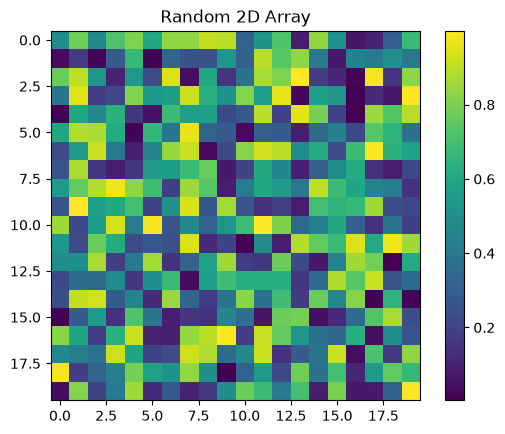

In [35]:
img = np.random.rand(20, 20)

plt.imshow(img)
plt.colorbar()
plt.title("Random 2D Array")
plt.show()

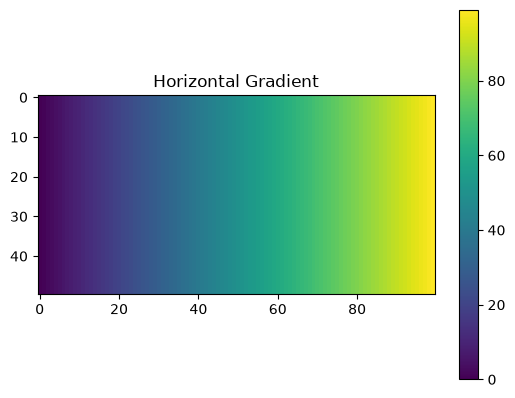

In [36]:
gradient = np.tile(np.arange(100), (50, 1))

plt.imshow(gradient)
plt.colorbar()
plt.title("Horizontal Gradient")
plt.show()

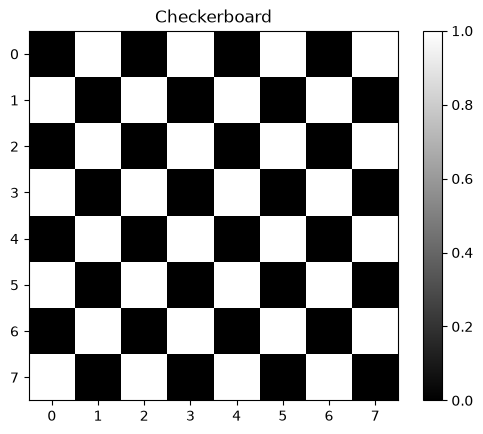

In [37]:
board = np.zeros((8, 8))

board[::2, 1::2] = 1
board[1::2, ::2] = 1

plt.imshow(board, cmap="gray")
plt.colorbar()
plt.title("Checkerboard")
plt.show()

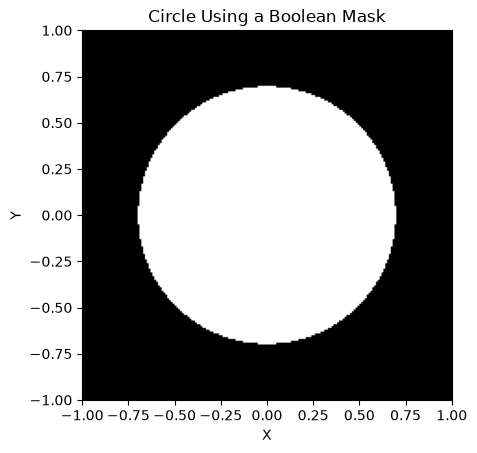

In [38]:
x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)

X, Y = np.meshgrid(x, y)

radius = 0.7

circle = X**2 + Y**2 <= radius**2

plt.imshow(circle, extent=(-1, 1, -1, 1), cmap="gray")
plt.title("Circle Using a Boolean Mask")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Shape: (100, 100)
Data type: uint8


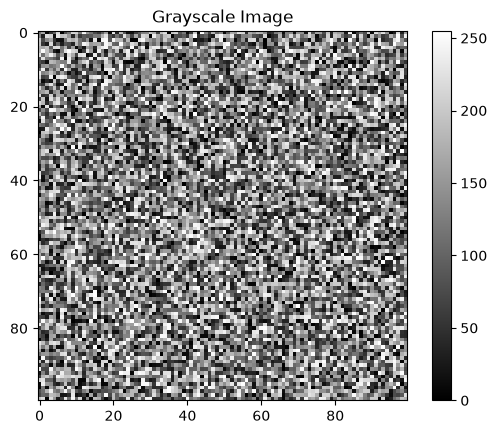

In [39]:
gray_image = np.random.randint(
    0,
    256,
    size=(100, 100),
    dtype=np.uint8
)

print("Shape:", gray_image.shape)
print("Data type:", gray_image.dtype)

plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.colorbar()
plt.show()

Quarter shape: (50, 50)


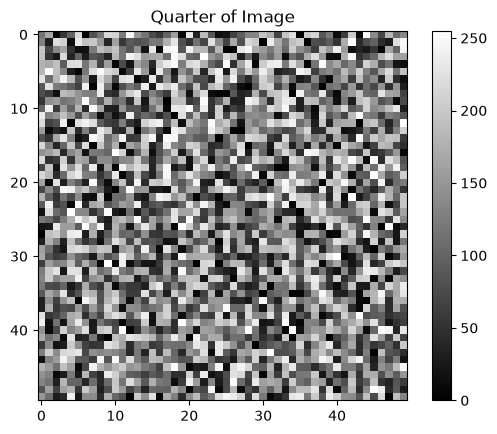

In [41]:
quarter = gray_image[:50, :50]

print("Quarter shape:", quarter.shape)

plt.imshow(quarter, cmap="gray")
plt.title("Quarter of Image")
plt.colorbar()
plt.show()

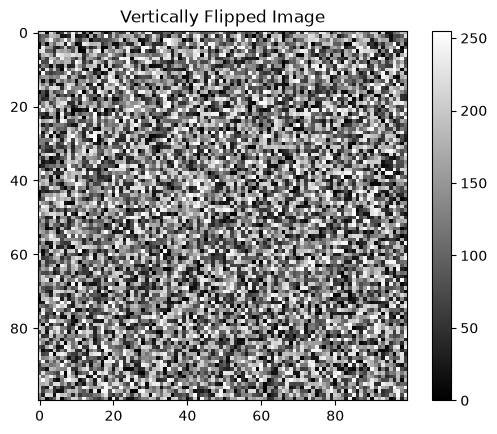

In [42]:
flipped = gray_image[::-1, :]
plt.imshow(flipped, cmap="gray")
plt.title("Vertically Flipped Image")
plt.colorbar()
plt.show()

In [43]:
import numpy as np

rng = np.random.default_rng(42)

marks = rng.integers(30, 101, size=(100, 5))

print("Marks:")
print(marks)

print("Shape:", marks.shape)

Marks:
[[ 36  84  76  61  60]
 [ 90  36  79  44  36]
 [ 67  99  82  84  80]
 [ 85  66  39  89  61]
 [ 65  56  42  95  85]
 [ 75  58  88  68  61]
 [ 61  46  36  69  93]
 [ 34  90  88  49  74]
 [ 41  83  79  55  34]
 [ 98  61  93  78  85]
 [ 83  43  55  63  65]
 [ 33  68  40  82  78]
 [ 95  82  56  98  59]
 [ 53  94  56  35  63]
 [ 86  43  62  39  78]
 [ 63  53  46  70  77]
 [ 96  61  41  89  74]
 [ 79  36  52  84  89]
 [ 60  87  89  57  93]
 [ 50  47  78  75  39]
 [ 89  44  87  30  86]
 [ 85  85  77  63  80]
 [ 49  85  69  62  65]
 [ 70  32  39  47  38]
 [ 61  77  76  63  90]
 [ 70  35  84  70  75]
 [ 70  69  36  69  86]
 [ 51  72  32  54  61]
 [ 99  45  49  59 100]
 [ 90  32  46  88  34]
 [ 90  49  95  50  60]
 [ 76  38  69  65  85]
 [100  77  59  58  59]
 [ 87  52  41  53  31]
 [ 37  36  84  81  79]
 [ 62  80  41  93  65]
 [ 96  40  65  79  65]
 [ 61  41  57  46  51]
 [ 78  74  73  55  98]
 [ 36  54  38  54  98]
 [ 56  94  65  79  62]
 [ 48  84  98  48  85]
 [ 48  80  86  61  82]
 [ 4

In [44]:
student_average = marks.mean(axis=1)

print("Student averages:")
print(student_average)

print("Shape:", student_average.shape)

Student averages:
[63.4 57.  82.4 68.  68.6 70.  61.  67.  58.4 83.  61.8 60.2 78.  60.2
 61.6 61.8 72.2 68.  77.2 57.8 67.2 78.  66.  45.2 73.4 66.8 66.  54.
 70.4 58.  68.8 66.6 70.6 52.8 63.4 68.2 69.  51.2 75.6 56.  71.2 72.6
 71.4 55.  61.  63.8 66.  68.6 59.2 58.8 55.8 53.6 74.8 66.  55.6 56.2
 63.  67.6 70.6 59.6 66.8 49.6 57.6 83.6 71.2 46.6 65.2 75.6 71.8 65.4
 61.8 70.4 71.8 59.2 67.2 61.  60.4 58.8 66.8 53.8 80.  58.2 41.4 66.
 77.6 66.6 60.8 59.2 63.8 68.4 72.2 62.  58.4 69.8 73.4 64.  66.6 64.6
 78.4 61.6]
Shape: (100,)


In [45]:
exam_average = marks.mean(axis=0)

print("Exam averages:")
print(exam_average)

print("Shape:", exam_average.shape)

Exam averages:
[66.81 64.08 63.03 64.55 66.17]
Shape: (5,)


In [60]:
import numpy as np

# 1. Generate reproducible data
rng = np.random.default_rng(42)
marks = rng.integers(30, 101, size=(100, 5))

# 2. Calculate averages
student_average = marks.mean(axis=1)
exam_average = marks.mean(axis=0)

print("Student averages:")
print(student_average)

print("\nExam averages:")
print(exam_average)

# 3. Passing students
passed = student_average >= 60
num_passed = passed.sum()
pass_fraction = num_passed / len(student_average)

print("\nNumber passed:", num_passed)
print("Pass fraction:", pass_fraction)
print("Pass percentage:", pass_fraction * 100)

# 4. Top 10 students
top_indices = np.argsort(student_average)[-10:][::-1]
top_scores = student_average[top_indices]

print("\nTop 10 student indices:")
print(top_indices)

print("\nTop 10 student scores:")
print(top_scores)

# 5. Standardise marks per exam
exam_mean = marks.mean(axis=0, keepdims=True)
exam_std = marks.std(axis=0, keepdims=True)

standardized_marks = (marks - exam_mean) / exam_std

print("\nStandardised exam means:")
print(standardized_marks.mean(axis=0))

print("\nStandardised exam standard deviations:")
print(standardized_marks.std(axis=0))

# 6. Apply +5 curve and cap at 100
curved_marks = np.clip(marks + 5, 0, 100)

num_hit_cap = (curved_marks == 100).sum()

print("\nMarks that hit 100:", num_hit_cap)

# 7. Students who failed every exam
failed_every_exam = np.all(marks < 60, axis=1)
failed_students = np.where(failed_every_exam)[0]

print("\nStudents who failed every exam:")
print(failed_students)

Student averages:
[63.4 57.  82.4 68.  68.6 70.  61.  67.  58.4 83.  61.8 60.2 78.  60.2
 61.6 61.8 72.2 68.  77.2 57.8 67.2 78.  66.  45.2 73.4 66.8 66.  54.
 70.4 58.  68.8 66.6 70.6 52.8 63.4 68.2 69.  51.2 75.6 56.  71.2 72.6
 71.4 55.  61.  63.8 66.  68.6 59.2 58.8 55.8 53.6 74.8 66.  55.6 56.2
 63.  67.6 70.6 59.6 66.8 49.6 57.6 83.6 71.2 46.6 65.2 75.6 71.8 65.4
 61.8 70.4 71.8 59.2 67.2 61.  60.4 58.8 66.8 53.8 80.  58.2 41.4 66.
 77.6 66.6 60.8 59.2 63.8 68.4 72.2 62.  58.4 69.8 73.4 64.  66.6 64.6
 78.4 61.6]

Exam averages:
[66.81 64.08 63.03 64.55 66.17]

Number passed: 73
Pass fraction: 0.73
Pass percentage: 73.0

Top 10 student indices:
[63  9  2 80 98 21 12 84 18 38]

Top 10 student scores:
[83.6 83.  82.4 80.  78.4 78.  78.  77.6 77.2 75.6]

Standardised exam means:
[-1.03250741e-16  7.54951657e-17 -6.55031585e-17  1.79856130e-16
 -1.09912079e-16]

Standardised exam standard deviations:
[1. 1. 1. 1. 1.]

Marks that hit 100: 44

Students who failed every exam:
[82]
